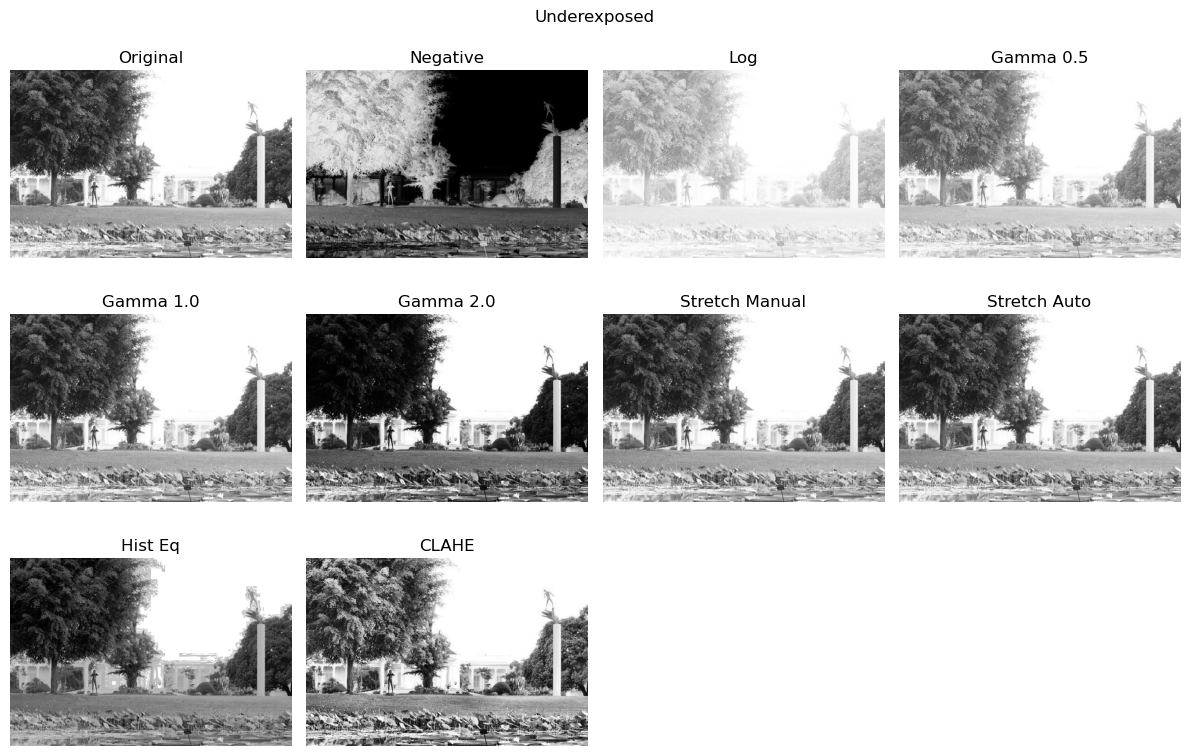

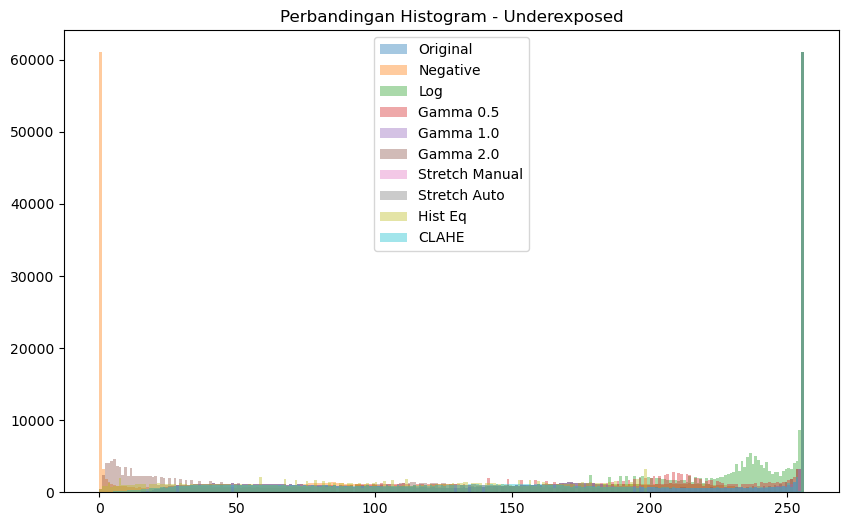


Evaluasi untuk: Underexposed
Original
Contrast Ratio : 255
Entropy : 6.857034248277263
----------------------
Negative
Contrast Ratio : 255
Entropy : 6.857034248277263
----------------------
Log
Contrast Ratio : 255
Entropy : 5.814664127241071
----------------------
Gamma 0.5
Contrast Ratio : 255
Entropy : 6.476116719581742
----------------------
Gamma 1.0
Contrast Ratio : 255
Entropy : 6.857034248277263
----------------------
Gamma 2.0
Contrast Ratio : 255
Entropy : 6.456717245169471
----------------------
Stretch Manual
Contrast Ratio : 255
Entropy : 6.857034248277263
----------------------
Stretch Auto
Contrast Ratio : 255
Entropy : 6.857034248277263
----------------------
Hist Eq
Contrast Ratio : 255
Entropy : 6.606836173396845
----------------------
CLAHE
Contrast Ratio : 255
Entropy : 6.910573093538865
----------------------


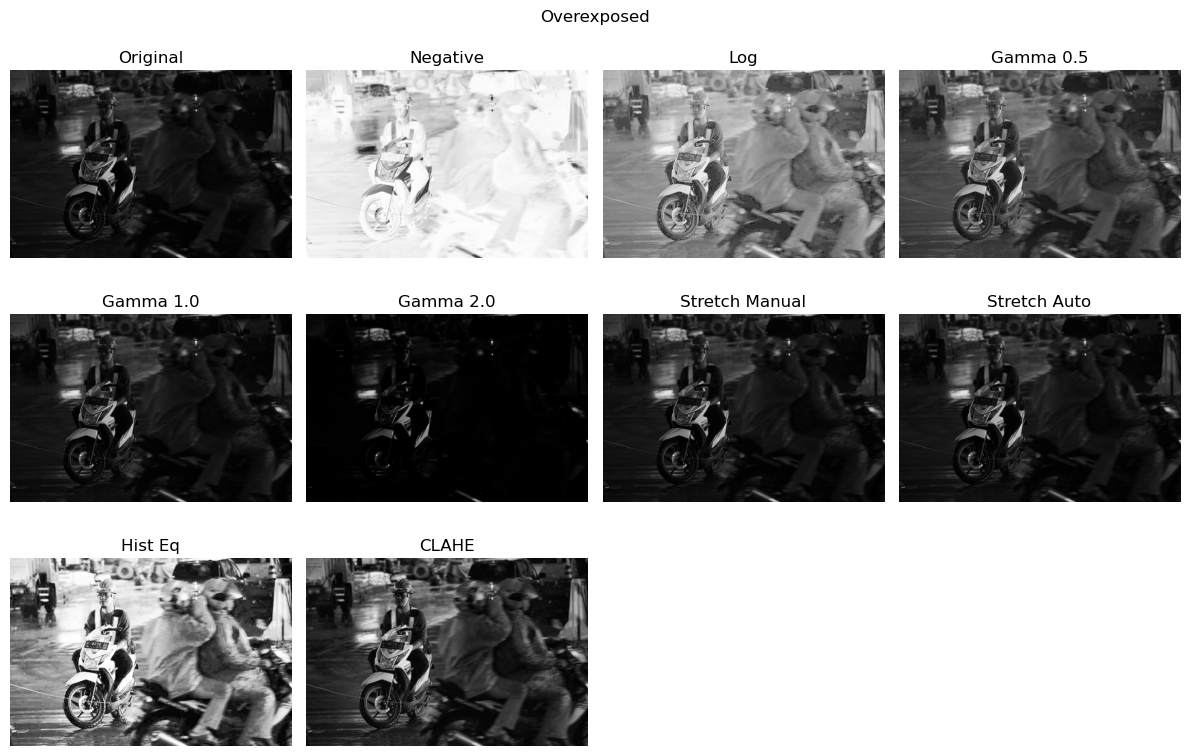

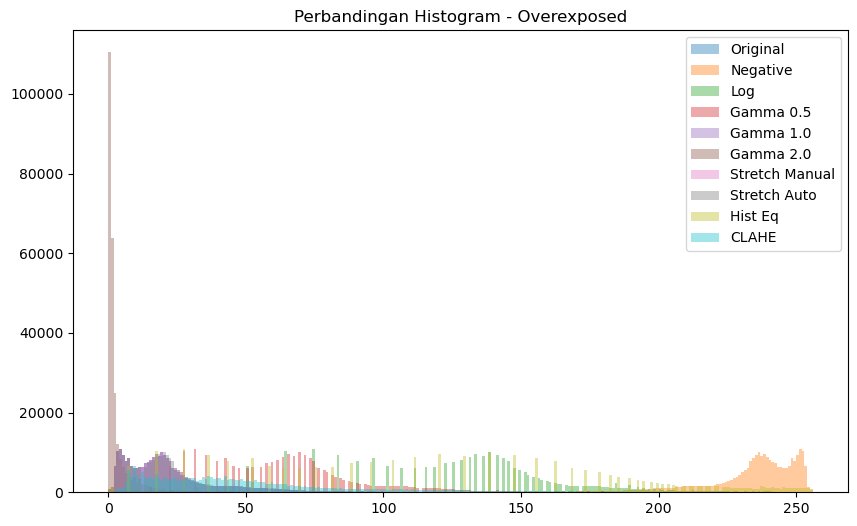


Evaluasi untuk: Overexposed
Original
Contrast Ratio : 244
Entropy : 5.968130809690887
----------------------
Negative
Contrast Ratio : 244
Entropy : 5.968130809690886
----------------------
Log
Contrast Ratio : 255
Entropy : 5.873318264952246
----------------------
Gamma 0.5
Contrast Ratio : 249
Entropy : 5.945158016534939
----------------------
Gamma 1.0
Contrast Ratio : 244
Entropy : 5.968130809690887
----------------------
Gamma 2.0
Contrast Ratio : 233
Entropy : 3.1714657432987448
----------------------
Stretch Manual
Contrast Ratio : 255
Entropy : 5.968130809690887
----------------------
Stretch Auto
Contrast Ratio : 255
Entropy : 5.968130809690887
----------------------
Hist Eq
Contrast Ratio : 255
Entropy : 5.7888450164201455
----------------------
CLAHE
Contrast Ratio : 251
Entropy : 7.038747669813
----------------------


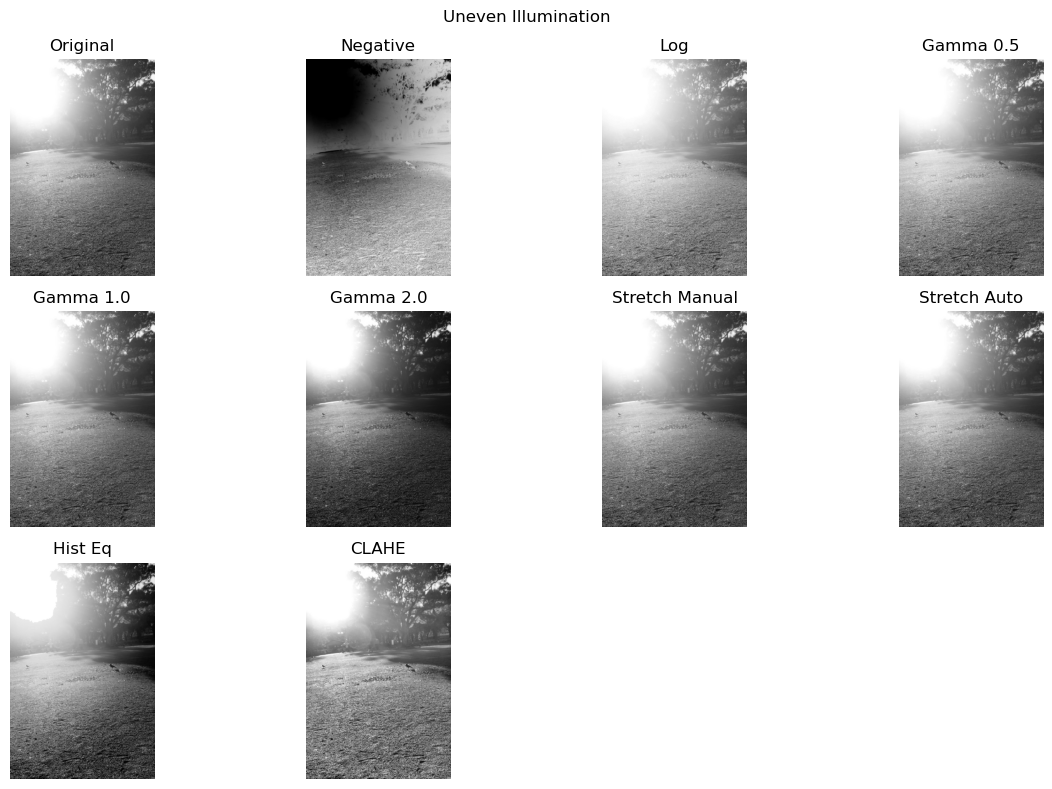

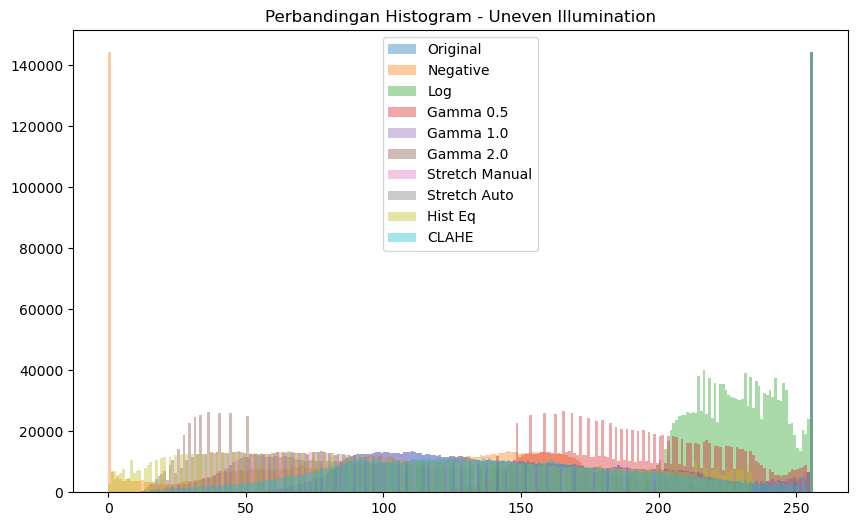


Evaluasi untuk: Uneven Illumination
Original
Contrast Ratio : 208
Entropy : 7.250167077211948
----------------------
Negative
Contrast Ratio : 208
Entropy : 7.250167077211946
----------------------
Log
Contrast Ratio : 77
Entropy : 5.767861879664099
----------------------
Gamma 0.5
Contrast Ratio : 146
Entropy : 6.678444518983572
----------------------
Gamma 1.0
Contrast Ratio : 208
Entropy : 7.250167077211948
----------------------
Gamma 2.0
Contrast Ratio : 247
Entropy : 7.0973274290095985
----------------------
Stretch Manual
Contrast Ratio : 255
Entropy : 7.250167077211948
----------------------
Stretch Auto
Contrast Ratio : 255
Entropy : 7.250167077211948
----------------------
Hist Eq
Contrast Ratio : 255
Entropy : 7.13904689102315
----------------------
CLAHE
Contrast Ratio : 245
Entropy : 7.452569053899805
----------------------


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import shannon_entropy

# ==============================
# Membaca 3 citra
# ==============================
under = cv2.imread("underexposed.jpeg", 0)
over = cv2.imread("overexposed.jpeg", 0)
uneven = cv2.imread("uneven.jpeg", 0)

images = {
    "Underexposed": under,
    "Overexposed": over,
    "Uneven Illumination": uneven
}

# ==============================
# POINT PROCESSING
# ==============================

# Negative Transformation
def negative_transform(img):
    return 255 - img

# Log Transformation
def log_transform(img):
    img_float = img.astype(np.float32)
    log_img = np.log1p(img_float)                 
    log_img = log_img / np.max(log_img) * 255     
    return log_img.astype(np.uint8)

# Gamma Correction
def gamma_transform(img, gamma):
    gamma_corrected = np.power(img / 255.0, gamma)
    return np.uint8(gamma_corrected * 255)

# ==============================
# HISTOGRAM BASED ENHANCEMENT
# ==============================

# Contrast Stretching Manual
def contrast_stretch_manual(img):
    r_min = np.min(img)
    r_max = np.max(img)
    stretched = (img - r_min) * (255 / (r_max - r_min))
    return np.uint8(stretched)

# Contrast Stretching Otomatis
def contrast_stretch_auto(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

# Histogram Equalization
def hist_equalization(img):
    return cv2.equalizeHist(img)

# CLAHE
def clahe_enhancement(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)

# ==============================
# METRIK EVALUASI
# ==============================

def contrast_ratio(img):
    return img.max() - img.min()

def entropy_value(img):
    return shannon_entropy(img)

# ==============================
# PROSES SEMUA CITRA
# ==============================

for name, img in images.items():

    negative = negative_transform(img)
    log_img = log_transform(img)

    gamma05 = gamma_transform(img, 0.5)
    gamma1 = gamma_transform(img, 1.0)
    gamma2 = gamma_transform(img, 2.0)

    stretch_manual = contrast_stretch_manual(img)
    stretch_auto = contrast_stretch_auto(img)

    hist_eq = hist_equalization(img)
    clahe_img = clahe_enhancement(img)

    results = {
        "Original": img,
        "Negative": negative,
        "Log": log_img,
        "Gamma 0.5": gamma05,
        "Gamma 1.0": gamma1,
        "Gamma 2.0": gamma2,
        "Stretch Manual": stretch_manual,
        "Stretch Auto": stretch_auto,
        "Hist Eq": hist_eq,
        "CLAHE": clahe_img
    }

    # ==============================
    # VISUALISASI GAMBAR
    # ==============================

    plt.figure(figsize=(12,8))
    plt.suptitle(name)

    i = 1
    for title, image in results.items():
        plt.subplot(3,4,i)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
        i += 1

    plt.tight_layout()
    plt.show()

    # ==============================
    # HISTOGRAM
    # ==============================

    plt.figure(figsize=(10,6))
    for title, image in results.items():
        plt.hist(image.ravel(), bins=256, range=(0,256), alpha=0.4, label=title)

    plt.title("Perbandingan Histogram - " + name)
    plt.legend()
    plt.show()

    # ==============================
    # METRIK KUANTITATIF
    # ==============================

    print("\nEvaluasi untuk:", name)

    for title, image in results.items():
        print(title)
        print("Contrast Ratio :", contrast_ratio(image))
        print("Entropy :", entropy_value(image))
        print("----------------------")